In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset Display
df_train = pd.read_csv(r"C:\Users\smart\OneDrive\Documents\Semester 10\Machine Learning\car_crash_train.csv")

df_train.head()

df_test = pd.read_csv(r"C:\Users\smart\OneDrive\Documents\Semester 10\Machine Learning\car_crash_test.csv")




Identifing Features!

 Numeric: Index(['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
       'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
       'Visibility Distance (m)'],
      dtype='str')

 Categorical: Index(['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
       'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition',
       'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density',
       'Severity'],
      dtype='str')

 Missing Data:
Crash Speed (km/h)              0
Impact Angle (degrees)          0
Airbag Deployed                 0
Seatbelt Used                   0
Weather Conditions              0
Road Conditions                 0
Crash Type                      0
Vehicle Type                    0
Vehicle Age (years)             0
Brake Condition                 0
Tire Condition                  0
Driver Age                      0
Driver Experience (years)       0
Alcohol Level (BAC%)          

C:\Users\smart\AppData\Local\Temp\ipykernel_3100\379086431.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include=['object']).columns


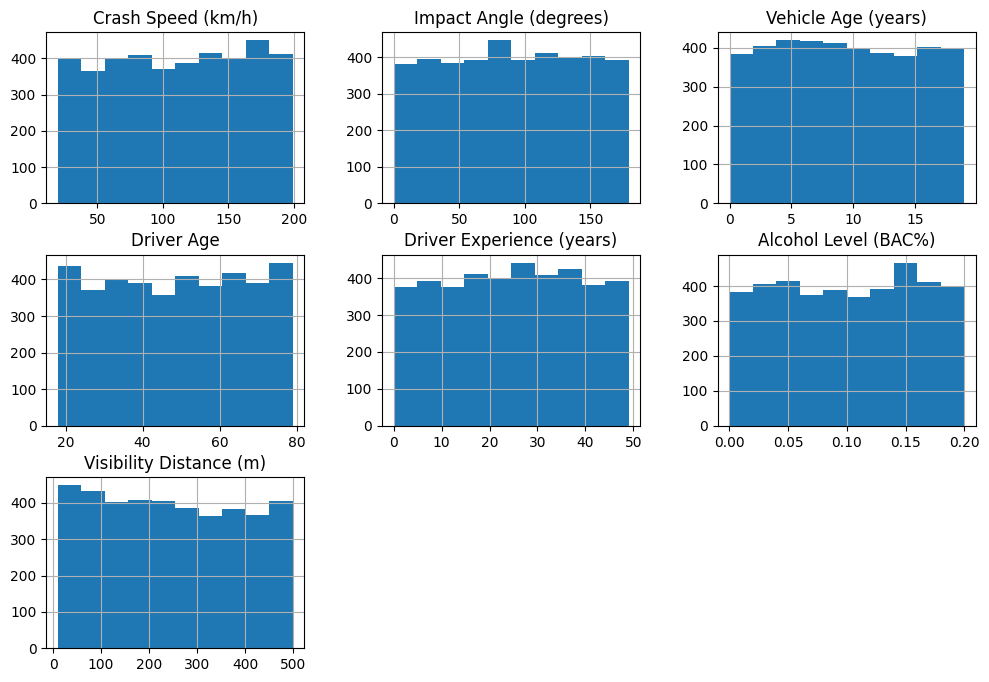

In [3]:
# Visalize Dataset
# 1) Identify Numeric vs Categorical Features
print("Identifing Features!")
numeric_cols = df_train.select_dtypes(include=['int64','float64']).columns
categorical_cols = df_train.select_dtypes(include=['object']).columns

print("\n","Numeric:", numeric_cols)
print("\n","Categorical:", categorical_cols)


# 2) Missing data

print( "\n","Missing Data:")
print(df_train.isnull().sum())

# 3) #Distribution of Numeric Features
df_train[numeric_cols].describe()
df_train[numeric_cols].skew()

df_train[numeric_cols].hist(figsize=(12,8))
plt.show()

In [4]:
# Pre-processing Train Data

# Split Features & Target
X = df_train.drop('Severity', axis=1)
y = df_train['Severity']

df_model = df_train.copy()

# 1-Handling Missing Values ( Distraction Level Feature has ~59% missing values)
df_model['Distraction Level'] = df_model['Distraction Level'].fillna('Unknown')

# 2-Encoding ( Applying One Hot Encoding)
X = pd.get_dummies(X)

# 3-Scaling ( Because the data is unbalanced - For KNN and LR)
from sklearn.preprocessing import  StandardScaler

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Training Dataset Shape",X.shape)

Training Dataset Shape (4000, 40)


Identifying Features!

Numeric: Index(['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
       'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
       'Visibility Distance (m)'],
      dtype='str')

Categorical: Index(['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
       'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition',
       'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density',
       'Severity'],
      dtype='str')

Missing Data:
Crash Speed (km/h)             0
Impact Angle (degrees)         0
Airbag Deployed                0
Seatbelt Used                  0
Weather Conditions             0
Road Conditions                0
Crash Type                     0
Vehicle Type                   0
Vehicle Age (years)            0
Brake Condition                0
Tire Condition                 0
Driver Age                     0
Driver Experience (years)      0
Alcohol Level (BAC%)           0
Distraction 

C:\Users\smart\AppData\Local\Temp\ipykernel_3100\2599660207.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_test = df_test.select_dtypes(include=['object']).columns


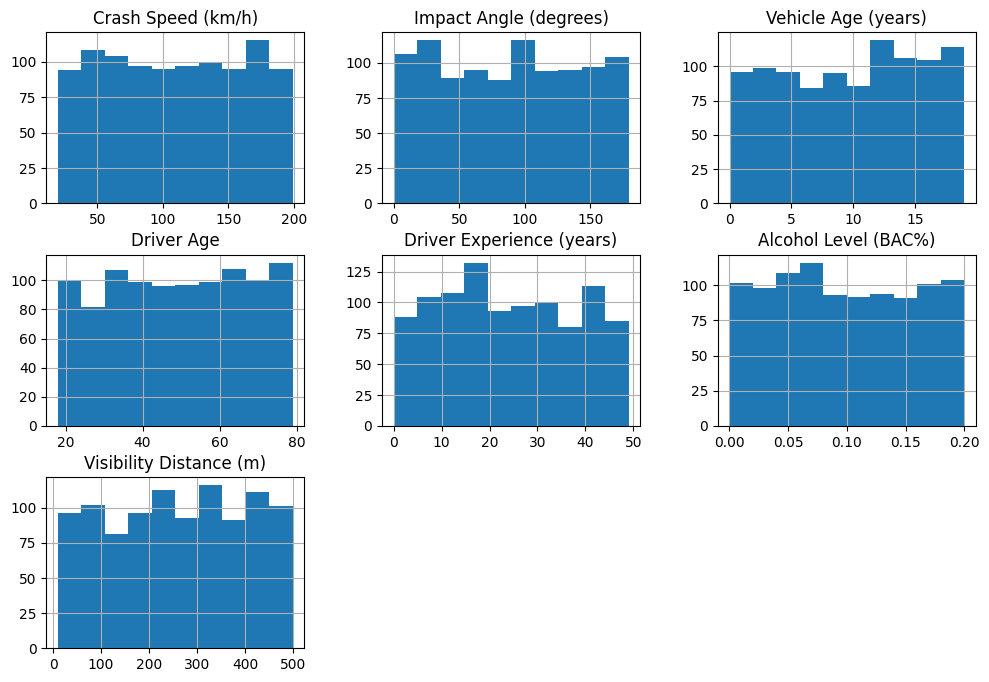

Testing Dataset Shape: (1000, 40)


In [5]:
#Testing CSV

# 1) Identify Features
print("Identifying Features!")

numeric_cols_test = df_test.select_dtypes(include=['int64','float64']).columns
categorical_cols_test = df_test.select_dtypes(include=['object']).columns

print("\nNumeric:", numeric_cols_test)
print("\nCategorical:", categorical_cols_test)

# 2) Missing data (FIXED)
print("\nMissing Data:")
print(df_test.isnull().sum())

# 3) Visualization (optional - OK)
df_test[numeric_cols_test].describe()
df_test[numeric_cols_test].skew()

df_test[numeric_cols_test].hist(figsize=(12,8))
plt.show()

# ==============================
# Preprocessing
# ==============================

# Separate target
y_test = df_test['Severity']
X_test = df_test.drop('Severity', axis=1)

# 1. Handle Missing Values
X_test['Distraction Level'] = X_test['Distraction Level'].fillna('Unknown')

# 2. Encoding
X_test = pd.get_dummies(X_test)

# 3. Align with training data (VERY IMPORTANT 🔥)
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

# 4. Scaling (USE SAME SCALER FROM TRAIN)
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ==============================
# Final Check
# ==============================
print("Testing Dataset Shape:", X_test.shape)


In [24]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

# Create Model
knn = KNeighborsClassifier(n_neighbors=5)

# Train Model
knn.fit(X, y)

# Predict on Test Data
y_pred = knn.predict(X_test)

# Model Evaluation
print("KNN Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

KNN Evaluation:
Accuracy: 0.652

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.06      0.02      0.04        41
 Minor Injury       0.71      0.88      0.78       710
Severe Injury       0.27      0.11      0.16       249

     accuracy                           0.65      1000
    macro avg       0.35      0.34      0.33      1000
 weighted avg       0.57      0.65      0.60      1000


Confusion Matrix:
[[  1  38   2]
 [ 13 623  74]
 [  2 219  28]]


In [25]:
# Decision Trees
from sklearn.tree import DecisionTreeClassifier

# Create Model
dt = DecisionTreeClassifier(random_state=42)

# Train Model
dt.fit(X, y)

# Predict on Test Data
y_pred_dt = dt.predict(X_test)

# Model Evaluation
print("Decision Tree Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Evaluation:
Accuracy: 0.542

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.07      0.06        41
 Minor Injury       0.71      0.66      0.68       710
Severe Injury       0.25      0.29      0.27       249

     accuracy                           0.54      1000
    macro avg       0.34      0.34      0.34      1000
 weighted avg       0.57      0.54      0.55      1000


Confusion Matrix:
[[  3  30   8]
 [ 37 468 205]
 [ 16 162  71]]


In [11]:
# Random Forests
from sklearn.ensemble import RandomForestClassifier

# Create Model
rf = RandomForestClassifier(
    n_estimators=100,        # number of trees
    class_weight='balanced',
    random_state=42
)

# Train Model
rf.fit(X, y)

# Predict on Test Data
y_pred_rf = rf.predict(X_test)

# Model Evaluation
print("Random Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Evaluation:
Accuracy: 0.71

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      1.00      0.83       710
Severe Injury       0.00      0.00      0.00       249

     accuracy                           0.71      1000
    macro avg       0.24      0.33      0.28      1000
 weighted avg       0.50      0.71      0.59      1000


Confusion Matrix:
[[  0  41   0]
 [  0 710   0]
 [  0 249   0]]


C:\Users\smart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\smart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\smart\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [10]:
# RANDOM FOREST + SMOTE

# Import Libraries
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Apply SMOTE to Balance Classes


smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class Distribution After SMOTE:")
print(y_resampled.value_counts())

# Random Forest Model

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf.fit(X_resampled, y_resampled)

# Predictions

y_pred_rf = rf.predict(X_test)

# Model Evaluation

print("Random Forest + SMOTE Performance")


print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Class Distribution After SMOTE:
Severity
Minor Injury     2756
Severe Injury    2756
Fatal            2756
Name: count, dtype: int64
Random Forest + SMOTE Performance
Accuracy: 0.696

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.25      0.02      0.04        41
 Minor Injury       0.71      0.96      0.82       710
Severe Injury       0.33      0.05      0.08       249

     accuracy                           0.70      1000
    macro avg       0.43      0.34      0.32      1000
 weighted avg       0.60      0.70      0.60      1000


Confusion Matrix:
[[  1  40   0]
 [  3 683  24]
 [  0 237  12]]


In [27]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Model
lr = LogisticRegression(
    max_iter=1000,          # important to avoid convergence issues
    class_weight='balanced', # helps with imbalanced data
    random_state=42
)

# Train Model
lr.fit(X, y)

# Predict on Test Data
y_pred_lr = lr.predict(X_test)

# Model Evaluation
print("Logistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Evaluation:
Accuracy: 0.324

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.49      0.10        41
 Minor Injury       0.72      0.31      0.43       710
Severe Injury       0.26      0.34      0.30       249

     accuracy                           0.32      1000
    macro avg       0.35      0.38      0.28      1000
 weighted avg       0.58      0.32      0.39      1000


Confusion Matrix:
[[ 20  10  11]
 [265 220 225]
 [ 91  74  84]]


In [28]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create Model
nb = GaussianNB()

# Train Model
nb.fit(X, y)

# Predict on Test Data
y_pred_nb = nb.predict(X_test)

# Model Evaluation
print("Naive Bayes Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Evaluation:
Accuracy: 0.689

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.72      0.95      0.82       710
Severe Injury       0.35      0.07      0.11       249

     accuracy                           0.69      1000
    macro avg       0.35      0.34      0.31      1000
 weighted avg       0.59      0.69      0.61      1000


Confusion Matrix:
[[  0  39   2]
 [  8 672  30]
 [  4 228  17]]


The experimental results demonstrated that overall accuracy alone was insufficient for evaluating performance due to severe class imbalance. Random Forest and Naive Bayes achieved the highest accuracy by heavily favoring the majority class (Minor Injury), while Logistic Regression and Decision Tree provided more balanced predictions and stronger minority-class detection. 

Logistic Regression achieved the best Fatal and Severe Injury recall, whereas Decision Tree offered a compromise between overall accuracy and minority-class recognition.

Although Random Forest achieved the highest overall accuracy, Logistic Regression was considered the most effective model for the crash severity classification task because it demonstrated significantly better detection of minority classes, particularly Fatal and Severe Injury cases. Since crash severity prediction is safety-critical, minority-class recall was prioritized over raw accuracy.

